In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd

import plotting
from analysis import load_runmap, load_baselines, load_metadata
from plotting import (
    plot_subject_boxplot, plot_subject_mean_boxplot,
    plot_subject_histogram, plot_subject_mean_histogram,
    plot_subjects_boxplot, plot_subjects_mean_boxplot,
    plot_group_pooled_boxplot, plot_group_mean_boxplot,
    plot_groups_pooled_boxplot, plot_groups_mean_boxplot,
)

runmap_df = load_runmap()
baselines_df = load_baselines()
metadata_df = load_metadata()

SESSION = 1
SUB_ID = 'MET000'
PERCENT = {'scope': 'run', 'trials': 'all', 'method': 'percent'}

# HC = the data's CTR (control) group label -- same categories as 03_group_comparisons
categories = [
    {'label': 'PD', 'group': 'PD'},
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]

## One participant -- all-run pixels
`flatten_runs` concatenates every run's grid into one array (400 values for `MET000`, or 300 for the ragged 3-run subjects). `normalize` is the same scope/trials/method dict used throughout the project -- shown here for raw and percent-change, but any method works.

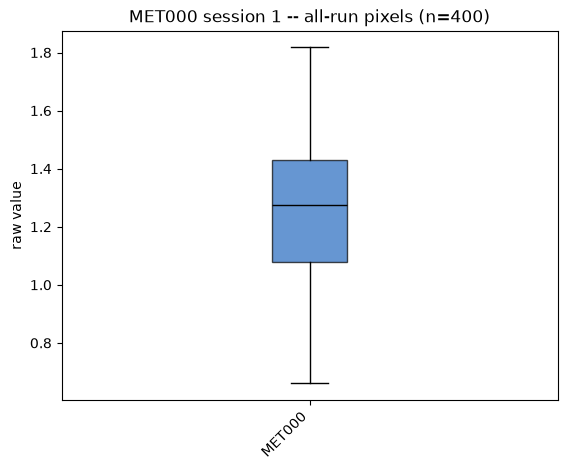

In [2]:
plot_subject_boxplot(runmap_df, baselines_df, SUB_ID, SESSION);

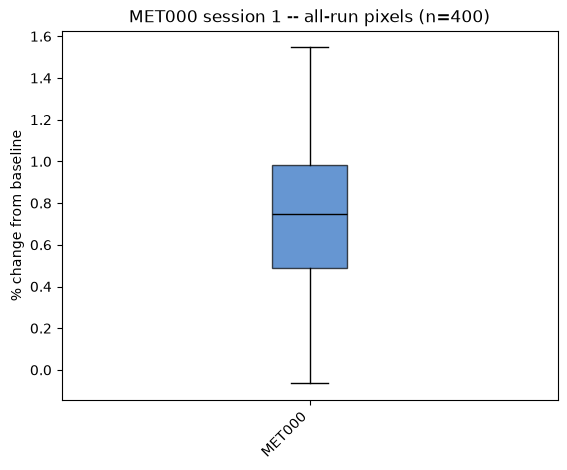

In [3]:
plot_subject_boxplot(runmap_df, baselines_df, SUB_ID, SESSION, normalize=PERCENT);

## One participant -- mean-grid pixels
First average across runs (10x10 grid), then flatten to 100 values.

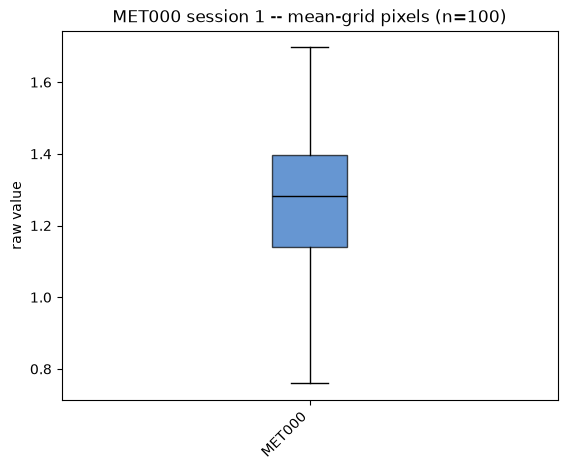

In [4]:
plot_subject_mean_boxplot(runmap_df, baselines_df, SUB_ID, SESSION);

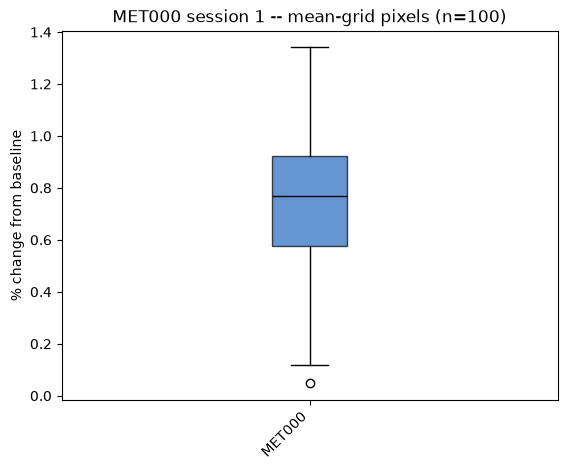

In [5]:
plot_subject_mean_boxplot(runmap_df, baselines_df, SUB_ID, SESSION, normalize=PERCENT);

## Same distributions, as histograms

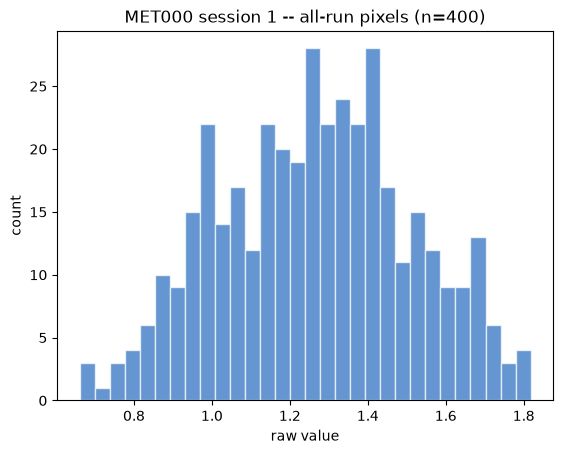

In [6]:
plot_subject_histogram(runmap_df, baselines_df, SUB_ID, SESSION);

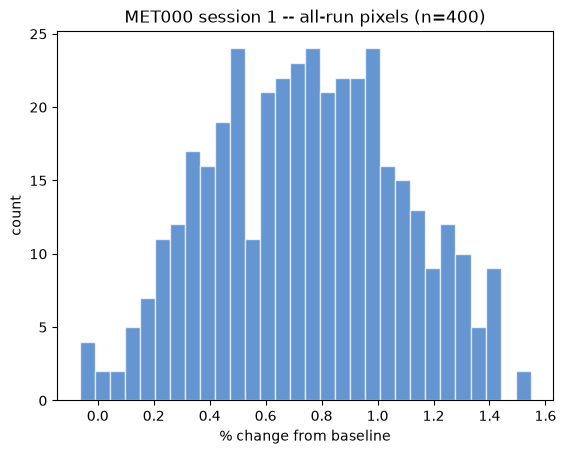

In [7]:
plot_subject_histogram(runmap_df, baselines_df, SUB_ID, SESSION, normalize=PERCENT);

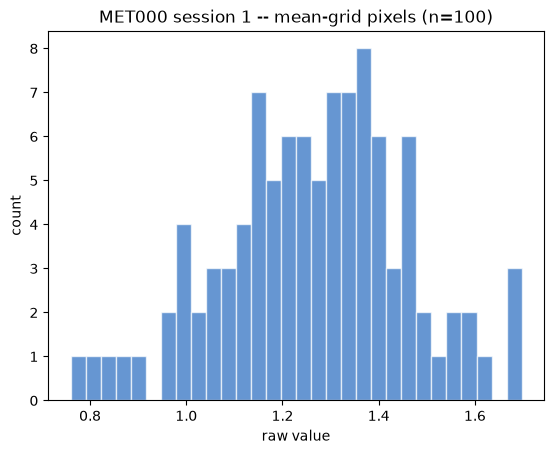

In [8]:
plot_subject_mean_histogram(runmap_df, baselines_df, SUB_ID, SESSION);

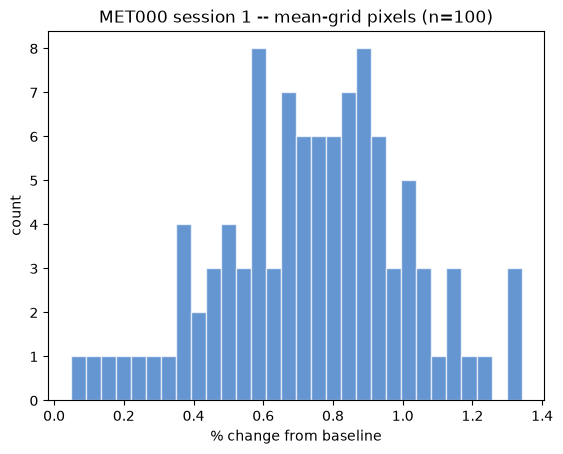

In [9]:
plot_subject_mean_histogram(runmap_df, baselines_df, SUB_ID, SESSION, normalize=PERCENT);

## Per-subject boxplots within a group
One box per subject, side by side -- all-run pixels for the full CTR group (n=34), mean-grid pixels for PD (n=10).

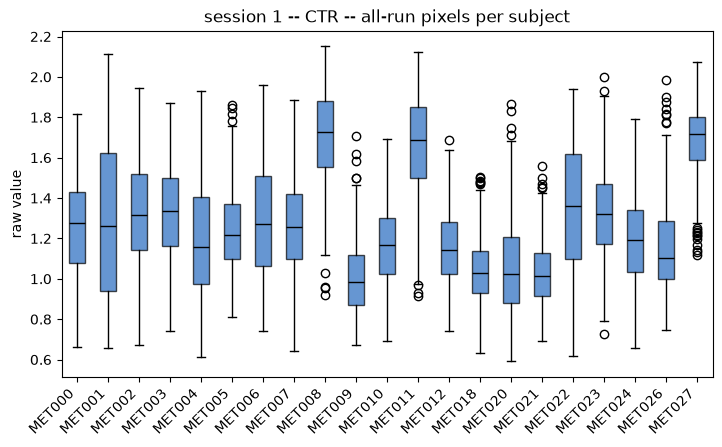

In [10]:
plot_subjects_boxplot(runmap_df, baselines_df, metadata_df, SESSION, group='CTR');

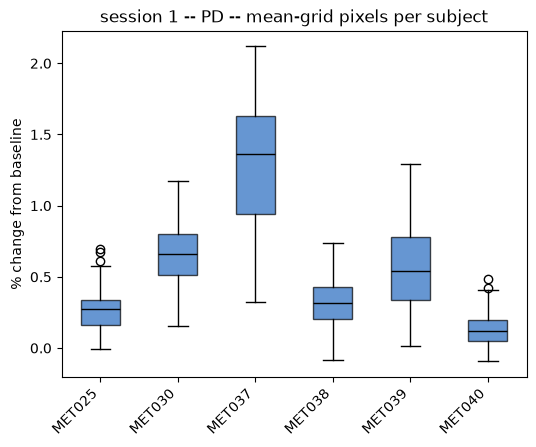

In [11]:
plot_subjects_mean_boxplot(runmap_df, baselines_df, metadata_df, SESSION, group='PD', normalize=PERCENT);

## Whole-group pooled distributions
Single box per group: all-run pixels of every subject pooled together (not averaged) vs. the group's mean-of-subject-means grid.

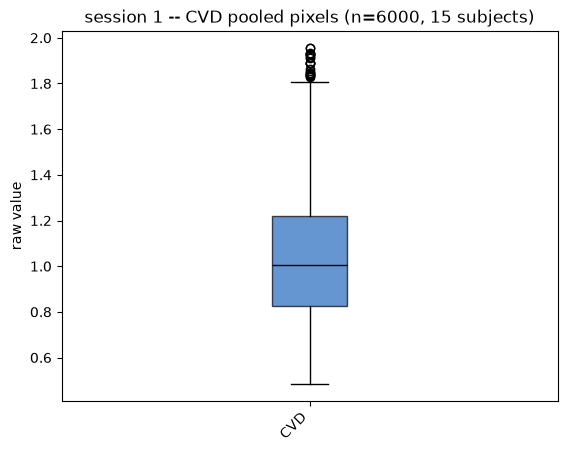

In [12]:
plot_group_pooled_boxplot(runmap_df, baselines_df, metadata_df, SESSION, group='CVD');

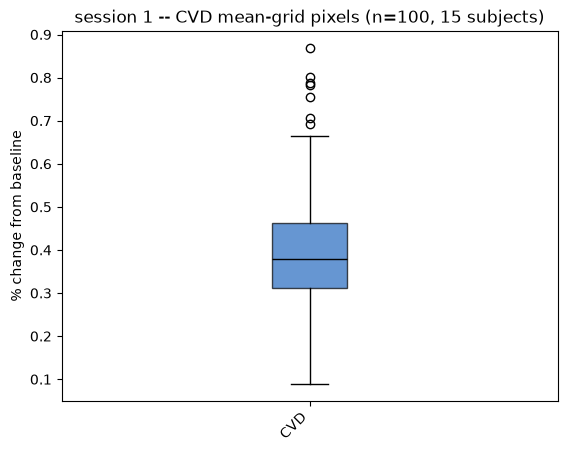

In [13]:
plot_group_mean_boxplot(runmap_df, baselines_df, metadata_df, SESSION, group='CVD', normalize=PERCENT);

## All groups side by side
PD, HC, protan, deutan (HD excluded, n=1) -- same `categories` convention as `plot_groups_side_by_side` in `03_group_comparisons.ipynb`.

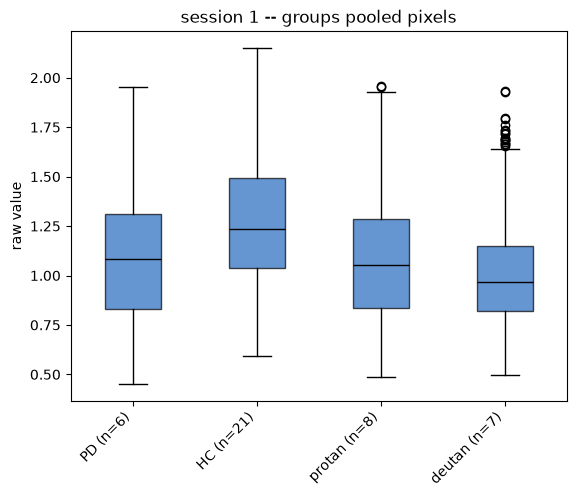

In [14]:
plot_groups_pooled_boxplot(runmap_df, baselines_df, metadata_df, SESSION, categories);

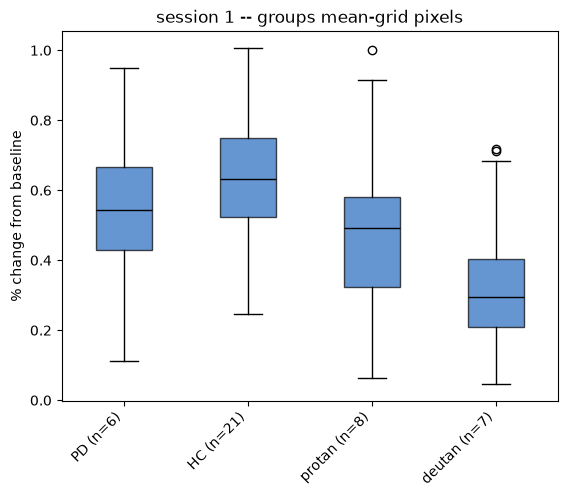

In [15]:
plot_groups_mean_boxplot(runmap_df, baselines_df, metadata_df, SESSION, categories, normalize=PERCENT);

## Trough summary tables
`analysis.subject_troughs`/`group_troughs` locate each subject's/group's minimum (red, green, depth) on the native 10x10 grid -- depth defaults to % change from baseline, since raw magnitude isn't comparable across subjects. Persisted by `scripts/build_troughs.py` to `ssveps/files/subject_troughs.csv` and `group_troughs.csv` (rerun anytime; both are a straight recompute).

In [16]:
subject_troughs_df = pd.read_csv('../files/subject_troughs.csv', keep_default_na=False)
group_troughs_df = pd.read_csv('../files/group_troughs.csv')
subject_troughs_df.head()

,sub_id,session,group,subgroup,red,green,depth,red_idx,green_idx
0,MET000,1,CTR,NA,1422.222222,1333.333333,0.047615,4,6
1,MET000,2,CTR,NA,1066.666667,1111.111111,0.119613,3,5
2,MET001,1,CTR,NA,1777.777778,1333.333333,0.269713,5,6
3,MET002,1,CTR,NA,2844.444444,1111.111111,-0.003260,8,5
4,MET002,2,CTR,NA,1422.222222,1333.333333,0.065820,4,6


In [17]:
group_troughs_df

,label,session,n,red,green,depth,red_idx,green_idx
0,PD,1,6,1422.222222,1333.333333,0.112153,4,6
1,HC,1,21,1422.222222,1333.333333,0.246488,4,6
2,protan,1,8,1066.666667,1777.777778,0.064911,3,8
3,deutan,1,7,1422.222222,1111.111111,0.046751,4,5
4,PD,2,4,1422.222222,1333.333333,0.115461,4,6
5,HC,2,13,1422.222222,1333.333333,0.215459,4,6
6,protan,2,2,1066.666667,1777.777778,0.043298,3,8


### Sanity check: trough locations
One marker shape per group/category (not color -- see `plot_trough_scatter`'s docstring). Mostly clustered in the same broad region, consistent with the flat trough already validated against independent ground truth in M1.

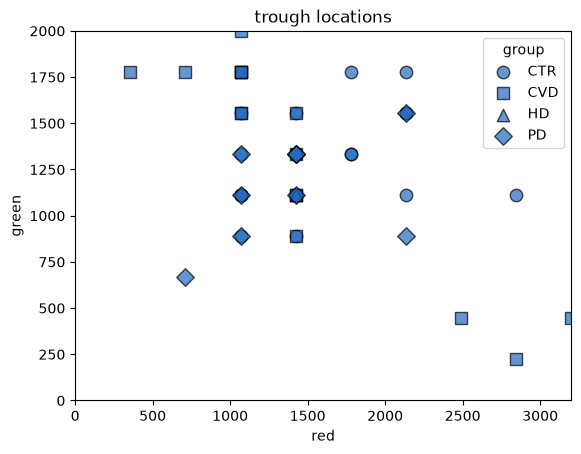

In [18]:
plotting.plot_trough_scatter(subject_troughs_df, 'group');

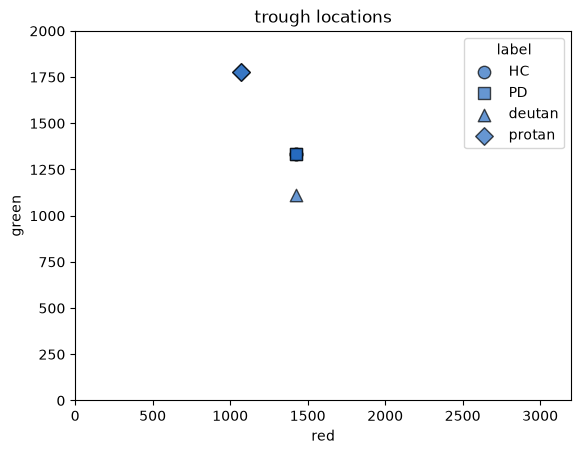

In [19]:
plotting.plot_trough_scatter(group_troughs_df, 'label');